# Session 2 — Demo 3 — SQL: same verbs, where data actually lives (+ the pickle)

**What this demo covers.** In a company, data doesn't sit in parquet files on your laptop. It sits in **databases**, and databases speak **SQL**. Good news: SQL is not a new subject; it's the same five verbs with a different spelling. We build a real database file, run the same questions in both tools, let an AI translate between them, and finally open `warehouse_info.pickle`. An optional **⚡ Extras** at the end redoes the pay math in pure SQL.

**Data.** Same ALPHA week — [data dictionary](../../data/README.md).

**How to run.** Locally: top to bottom (creates `warehouse.db` next to the notebook). Colab: uncomment the lines in the setup cell.

## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib

## 1. What a database is — and what a query is

A **database** is a program with one job: store tables and answer questions about them. Reliably, for many users at once, on data far bigger than any laptop's memory. Your bank's transactions and your company's orders and logs are sitting in one right now.

You don't scroll a database. You send it a **query**, one sentence in the SQL language, and it sends back a table. That is the whole interaction. And the sentence is built from the five verbs you already own, written in a fixed clause order:

```sql
SELECT   user_id, COUNT(*) AS picks     -- select columns (and compute aggregates)
FROM     picking_events                 -- which table
WHERE    event_type = 'PickWrongItem'   -- filter rows
GROUP BY user_id                        -- aggregate: split into piles
ORDER BY picks DESC                     -- sort
LIMIT    10                             -- head()
```

You never need all the lines; `SELECT ... FROM ...` alone is a complete query. Tonight's database is **sqlite**: a complete database living in a single file, with no server and no password. It genuinely ships inside many apps on your phone. Python talks to it out of the box.

## 2. Build the database (yes, really)

One nuance before loading our events into it: sqlite has no true datetime type (a classic gotcha), so we ship ready-made columns instead of the raw timestamp: the date as text (`.astype(str)` converts a column's type) and the hour as a number. `.copy()` first, so the original `events` stays untouched. And `drop(columns=...)` is select's mirror: name what to remove instead of what to keep:

In [2]:
events = pd.read_parquet(DATA / "picking_events.parquet")
topology = pd.read_parquet(DATA / "topology.parquet")

events_sql = events.copy()
events_sql["event_date"] = events_sql["event_time"].dt.date.astype(str)
events_sql["hour"] = events_sql["event_time"].dt.hour
events_sql = events_sql.drop(columns=["event_time"])
events_sql.head()

,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason,event_date,hour
0,StartTask,4500859,800000001,NaN,NaN,NaN,NaN,NaN,2026-03-02,11
1,ScanCell,4500859,800000001,54400900.0,NaN,NaN,135.0,NaN,2026-03-02,11
2,PickWrongItem,4500859,800000001,54400900.0,10000001.0,3.014677e+09,135.0,WRONG_ITEM,2026-03-02,11
3,PickCorrectItem,4500859,800000001,54400900.0,10000001.0,1.679524e+09,135.0,NaN,2026-03-02,11
4,ScanCell,4500859,800000001,43583220.0,NaN,NaN,12.0,NaN,2026-03-02,11


Let's open a connection to the database. Python speaks sqlite out of the box, through the built-in `sqlite3` library, so there is nothing to install. If the database file doesn't exist yet, sqlite creates it.

One line of housekeeping first: `unlink` deletes a file, and `missing_ok=True` means *don't complain if it isn't there*. We delete the old database so that re-running this notebook always builds it from scratch.

In [3]:
import sqlite3

Path("warehouse.db").unlink(missing_ok=True)   # fresh start on re-runs
con = sqlite3.connect("warehouse.db")
con

Now write both tables into the database; pandas does it in one call. `to_sql` is `read_sql` in reverse: it takes a DataFrame and creates a table from it. Then we ask the operating system how big the new file is (`.stat().st_size` gives bytes, so dividing by a million gives megabytes):

In [4]:
events_sql.to_sql("picking_events", con, index=False)
topology.to_sql("topology", con, index=False)
print("warehouse.db:", f"{Path('warehouse.db').stat().st_size / 1e6:.1f} MB")

warehouse.db: 19.6 MB


That file is a database: `connect` opened it, and `to_sql` wrote our DataFrames into it as tables. You just built one.


## 3. The same questions, twice

Nothing below is a new idea. Every question here you already answered in pandas before the break; we are only learning a **second spelling** of the same five verbs.

> 🖼 **Keep the phrasebook open** — card 7 in `concept-cards.html`, in this folder: every verb in both languages, side by side.

So every question below runs in three steps:

1. **in pandas** — the line you already know how to write;
2. **in SQL** — `pd.read_sql(query, con)` sends the sentence and hands the answer back as a DataFrame;
3. **a check** that the two numbers are identical.

That third step is the habit, not the ceremony. Two tools that disagree mean one of them is wrong, and you would rather find out here than in a meeting.

### Question 1 — *filter*: how many wrong picks were there?

In pandas, a mask inside brackets:

In [5]:
wrong_pd = events_sql[events_sql["event_type"] == "PickWrongItem"]
wrong_pd[["event_date", "hour", "user_id", "cell_id"]].head()

,event_date,hour,user_id,cell_id
2,2026-03-02,11,4500859,54400900.0
21,2026-03-02,12,4500859,160985669.0
29,2026-03-02,12,4500859,55185393.0
50,2026-03-02,12,4500859,111723864.0
51,2026-03-02,12,4500859,111723864.0


In SQL, the same condition moves into a `WHERE` clause, and the columns you want move into `SELECT`.

Note the shape we'll use for every query tonight: **write the query into a variable, then send it.** Two short lines instead of one long call. The query stays a thing you can read on its own, print, re-run, or paste into a database console at work — and the line that sends it is short enough to see at a glance.

In [6]:
wrong_query = """
    SELECT event_date, hour, user_id, cell_id
    FROM picking_events
    WHERE event_type = 'PickWrongItem'
"""
wrong_sql = pd.read_sql(wrong_query, con)

print(
    f"wrong picks — pandas: {len(wrong_pd):,}   "
    f"SQL: {len(wrong_sql):,}   "
    f"match: {len(wrong_pd) == len(wrong_sql)}"
)
wrong_sql.head()

wrong picks — pandas: 33,317   SQL: 33,317   match: True


,event_date,hour,user_id,cell_id
0,2026-03-02,11,4500859,54400900.0
1,2026-03-02,12,4500859,160985669.0
2,2026-03-02,12,4500859,55185393.0
3,2026-03-02,12,4500859,111723864.0
4,2026-03-02,12,4500859,111723864.0


### Question 2 — *aggregate + sort*: who are the top pickers?

In pandas: split into piles, count, sort, head. Exactly the chain from Demo 1:

In [7]:
top_pd = (
    events_sql[events_sql["event_type"] == "PickCorrectItem"]
    .groupby("user_id")
    .size()
    .sort_values(ascending=False)
    .head(5)
)
top_pd

user_id
9051397    3097
6206221    2983
3145818    2772
9340963    2639
6962698    2626
dtype: int64

In SQL every step becomes its own clause, in a fixed order. This is the full anatomy from card 6, live.

The check underneath uses `.tolist()`, which turns a column into a plain Python list. Comparing two lists with `==` compares the numbers inside them, which is what we actually want to know:

In [8]:
top_query = """
    SELECT user_id, COUNT(*) AS picks
    FROM picking_events
    WHERE event_type = 'PickCorrectItem'
    GROUP BY user_id
    ORDER BY picks DESC
    LIMIT 5
"""
top_sql = pd.read_sql(top_query, con)

# .tolist() turns a column into a plain Python list, so == compares the numbers
print("same five workers, same counts:", top_pd.tolist() == top_sql["picks"].tolist())
top_sql

same five workers, same counts: True


,user_id,picks
0,9051397,3097
1,6206221,2983
2,3145818,2772
3,9340963,2639
4,6962698,2626


### Question 3 — *join*: which zone works hardest?

The pandas version is the merge from Demo 2, rebuilt here so we compare numbers rather than memories. `inner` on purpose this time, so that it mirrors exactly what SQL's plain `JOIN` will do:

In [9]:
picks_pd = events_sql[
    events_sql["event_type"].isin(["PickCorrectItem", "PickWrongItem"])
]

zone_pd = (
    picks_pd
    .merge(topology[["cell_id", "zone_id"]], on="cell_id", how="inner")
    .groupby("zone_id")
    .size()
)
zone_pd

zone_id
104959650    92332
121029085    86889
dtype: int64

The SQL version brings two new spellings with it:

- `FROM picking_events e` gives the table a one-letter **alias** — a nickname, so `t.zone_id` reads *"the zone column from topology"*. With two tables in one sentence you need it: both have a `cell_id`.
- `ON e.cell_id = t.cell_id` names the key explicitly — this is our `on=`.

And one warning worth memorizing: **SQL's plain `JOIN` is an *inner* join.** It drops unmatched rows exactly the way pandas did before the break, so write `LEFT JOIN` when you mean left.

In [10]:
zone_query = """
    SELECT t.zone_id, COUNT(*) AS picks
    FROM picking_events e
    JOIN topology t ON e.cell_id = t.cell_id
    WHERE e.event_type IN ('PickCorrectItem', 'PickWrongItem')
    GROUP BY t.zone_id
"""
zone_sql = pd.read_sql(zone_query, con)

print("pandas:", zone_pd.tolist())
print("SQL:   ", zone_sql["picks"].tolist())
print("match: ", zone_pd.tolist() == zone_sql["picks"].tolist())
zone_sql

pandas: [92332, 86889]
SQL:    [92332, 86889]
match:  True


,zone_id,picks
0,104959650,92332
1,121029085,86889


The same 92,332 / 86,889 we got an hour ago with `merge`. **Two tools, one truth** — and now you have proof rather than a promise.

### Question 4 — straight from a query into a chart

**Pull with SQL, polish with pandas** — the daily loop of a corporate analyst. The query's answer is already a DataFrame, so everything you learned in Session 1 still applies to it:

match: True


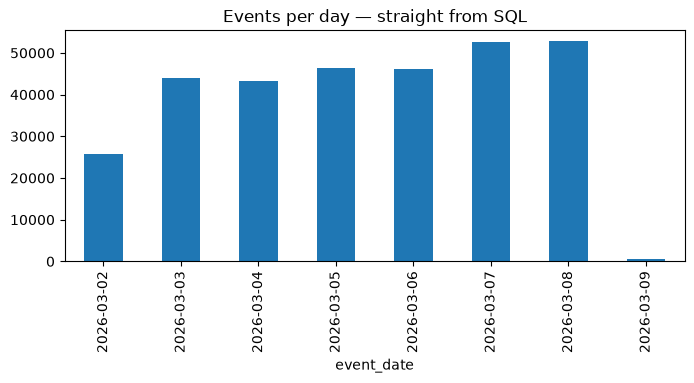

In [11]:
per_day_query = """
    SELECT event_date, COUNT(*) AS events
    FROM picking_events
    GROUP BY event_date
"""
per_day = pd.read_sql(per_day_query, con)

# the pandas twin, one last time
per_day_pd = events_sql.groupby("event_date").size()
print("match:", per_day["events"].tolist() == per_day_pd.tolist())

per_day.plot(
    x="event_date",
    y="events",
    kind="bar",
    figsize=(8, 3),
    legend=False,
    title="Events per day — straight from SQL",
)
plt.show()

## 4. The AI moment — the translator

Translating between tools is where an assistant is strongest: *you* know what you want (you wrote it in pandas an hour ago), and *it* knows the other spelling. The prompt: role, code, schema, and the **target dialect** (SQL has dialects, so say `sqlite` or you'll get someone else's syntax):

> You are a data analyst. Translate this pandas snippet to a single SQL query for **sqlite**. Table `picking_events` has columns: event_type, user_id, cell_id, event_date, hour. Table `topology` has: cell_id, sector_id, zone_id. Return only the SQL.
> ```python
> picks = events[events["event_type"] == "PickCorrectItem"]
> picks.merge(topology, on="cell_id").groupby("sector_id").size().sort_values(ascending=False)
> ```

Below is the returned SQL. Read it, run it, then **check it against the pandas numbers**, on counts rather than on vibes:

In [12]:
# — SQL returned by the assistant; read it, then run —
by_sector_query = """
    SELECT t.sector_id, COUNT(*) AS picks
    FROM picking_events e
    JOIN topology t ON e.cell_id = t.cell_id
    WHERE e.event_type = 'PickCorrectItem'
    GROUP BY t.sector_id
    ORDER BY picks DESC
"""
by_sector_sql = pd.read_sql(by_sector_query, con)

# the pandas truth to compare against
by_sector_pd = (
    events_sql[events_sql["event_type"] == "PickCorrectItem"]
    .merge(topology, on="cell_id")
    .groupby("sector_id")
    .size()
    .sort_values(ascending=False)
)

print("SQL == pandas:", by_sector_sql["picks"].tolist() == by_sector_pd.tolist())
by_sector_sql

SQL == pandas: True


,sector_id,picks
0,5400.0,35745
1,8089.0,24613
2,5130.0,23402
3,6794.0,19287
4,5659.0,16445
5,5402.0,15264
6,5761.0,11148


Equal — shipped. The loop again: think → formulate → verify.

## 5. The pickle, finally

One file in `data/alpha/` is not a table. A **pickle** is any Python object saved to disk: parquet is for tables, pickle is for everything else. Python reads it with the built-in `pickle` library, and `"rb"` in `open` means *read, in binary*, because a pickle is not text. (Safety rule: only open pickles you trust — arbitrary code can hide inside.)

In [13]:
import pickle

with open(DATA / "warehouse_info.pickle", "rb") as f:
    info = pickle.load(f)

info

{'warehouse_name': 'ALPHA',
 'period': {'from': '2026-03-02', 'to': '2026-03-08'},
 'currency': 'RUB',
 'pay_per_pick': 7.0,
 'night_bonus_mult': 1.25,
 'night_hours': [22, 6],
 'shift_guarantee': 2500.0,
 'box_volume_l': 72.0,
 'notes': 'Pickers are paid per successful pick (PickCorrectItem). Night picks are paid with the night bonus multiplier. If a shift earns less than shift_guarantee, the guarantee is paid instead.'}

It's a dictionary, a plain primer-§4 dictionary, and it holds the **pay rules** of the warehouse: the per-pick rate, the night multiplier, and a per-shift minimum guarantee (read `notes`). Let's use it: the naive week pay of the busiest picker. One new tool on the way: **`.map(dictionary)`** replaces every value in a column by looking it up in a dict — here `True → the night multiplier, False → 1`:

In [14]:
picks = events[events["event_type"] == "PickCorrectItem"].copy()
picks["hour"] = picks["event_time"].dt.hour

# night_hours is [22, 6]: the night shift starts at 22:00 and ends at 06:00
night_start, night_end = info["night_hours"]
picks["is_night"] = (
    (picks["hour"] >= night_start)
    | (picks["hour"] < night_end)
)

# .map(dict) swaps each True/False for the multiplier next to it in the dictionary
night_multiplier = picks["is_night"].map({
    True: info["night_bonus_mult"],
    False: 1.0,
})
picks["pay"] = info["pay_per_pick"] * night_multiplier

*Remember: you can always look at the table before moving on to the next step.* Here `.sample(5)` beats `.head()`: it returns five **random** rows, and the first rows of this table are all from Monday morning. We want to see a night row and a day row next to each other. `random_state=0` fixes the dice, so you and I draw the same five rows; leave it out and every run gives you a different five.

In [15]:
picks.sample(5, random_state=0)

,event_time,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason,hour,is_night,pay
119843,2026-03-05 02:07:05.121,PickCorrectItem,3903210,800910859,104864951.0,10058330.0,3.078574e+09,79.0,NaN,2,True,8.75
49885,2026-03-03 16:35:17.811,PickCorrectItem,8735343,800136944,74743745.0,10025563.0,2.176294e+09,9.0,NaN,16,False,7.00
64863,2026-03-03 22:10:13.544,PickCorrectItem,6962698,800582291,91680964.0,10032344.0,6.200338e+08,38.0,NaN,22,True,8.75
272699,2026-03-08 03:43:05.704,PickCorrectItem,8502518,801987442,67915779.0,10134634.0,1.856297e+09,18.0,NaN,3,True,8.75
261996,2026-03-08 00:55:08.236,PickCorrectItem,9460071,801928799,59199836.0,10128595.0,7.532125e+08,45.0,NaN,0,True,8.75


Now we can compute each picker's pay for the week.

In [16]:
pay_per_worker = (
    picks
    .groupby("user_id")["pay"]
    .sum()
    .sort_values(ascending=False)
)
print(
    f"top earner {pay_per_worker.index[0]} earned "
    f"≈ {pay_per_worker.values[0]:,.0f} {info['currency']} in pick pay this week"
)

top earner 6206221 earned ≈ 24,218 RUB in pick pay this week


Look at the id: it is **not** the top picker from question 2. The night multiplier reshuffles the ranking — whoever works nights earns more per pick. Rates change rankings, and that is a business fact, not a bug.

…and this number is still *naive*, because the third pay rule is per **shift**, and look at the columns: there is no `shift` column. What even *is* a shift in an event log? Where does one end and the next begin?

**Hold that thought.** In HW1 that question is yours — and it has no right answer, only defended ones.

## Try it yourself

1. In SQL: events per `event_type` — you already know the answer from `value_counts()`; that's your self-check.
2. Which **sector has the most cells** (topology), and is it the sector with the most **picks** (Demo 2)? One join, two groupbys — layout is not demand.
3. Stretch: **average picks per task by zone**, in either tool.

In [17]:
# your turn


---

## ⚡ Extras — power tools, not required

**The whole pay computation in pure SQL.** `CASE WHEN ... THEN ... ELSE ... END` is SQL's if/else, right inside the query — the night bonus becomes one expression, and `SUM(...)` adds it up per picker. Same question, second tool; the top number must agree with the pandas cell above:

In [18]:
# re-derived here so this cell runs on its own
rate, mult = info["pay_per_pick"], info["night_bonus_mult"]
night_start, night_end = info["night_hours"]

pay_query = f"""
    SELECT user_id,
           SUM(CASE WHEN hour >= {night_start} OR hour < {night_end}
                    THEN {rate} * {mult} ELSE {rate} END) AS pay
    FROM picking_events
    WHERE event_type = 'PickCorrectItem'
    GROUP BY user_id
    ORDER BY pay DESC
    LIMIT 3
"""
pd.read_sql(pay_query, con)

,user_id,pay
0,6206221,24218.25
1,9051397,22954.75
2,9682063,22125.25


## Recap

- SQL = the same five verbs where corporate data lives (`SELECT, FROM, WHERE, GROUP BY, ORDER BY`), plus `JOIN` for the second table, in a fixed clause order.
- A query is a sentence you send; a table is what comes back. **Pull with SQL, polish with pandas**; `read_sql` is the bridge.
- SQL's plain `JOIN` is an **inner** join, and it drops unmatched rows exactly like pandas does.
- Two tools must give one truth — **every query tonight was written twice and checked**; that comparison *is* the verification.
- AI translates between tools well — when you name the dialect and verify on numbers.
- Pickle = saved Python object (here: the pay rules). Parquet for tables. Only open pickles you trust.
- Unsure what a function or a clause does? The toy-table habit works here too — build three rows, load them, query them.
- "What is a shift?" — some columns don't exist; defining them is analyst work. See you in HW1.

*Next week: statistics and charts that don't lie — and a second warehouse, BRAVO, enters the story.*